In [ ]:
import pandas as pd
import numpy as np
import torch
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModel, BertTokenizerFast, DistilBertTokenizerFast, AutoTokenizer
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import os
import shap
import spacy
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from collections import defaultdict, Counter
import random
import pickle
import re

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
model_name = "distillbert"

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [ ]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df = pd.read_csv('../data/combined_letters_degendered.csv')

# Create Training and Test Sets

In [ ]:
train_text, temp_text, train_labels, temp_labels = train_test_split(df['full_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

In [ ]:
bert = AutoModel.from_pretrained("distilbert/distilbert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

In [ ]:
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

/tmp/ipython-input-2686642901.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_seq = torch.tensor(tokens_train['input_ids'])
/tmp/ipython-input-2686642901.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_mask = torch.tensor(tokens_train['attention_mask'])
/tmp/ipython-input-2686642901.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_seq = torch.tensor(tokens_val['input_ids'])
/tmp/ipython-input-2686642901.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or 

In [ ]:
batch_size = 16
train_data = TensorDataset(train_seq, train_mask, train_y)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_seq, val_mask, val_y)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)

In [ ]:
# freeze weights, uncomment if you would like to unfreeze weights
for param in bert.parameters():
    param.requires_grad = False


In [ ]:
# Unfreeze top 2 layers to start (layers 4 and 5)
for i in [4, 5]:
    for param in bert.transformer.layer[i].parameters():
        param.requires_grad = True


# Create Model

In [ ]:
class BERT_Arch(nn.Module):

    def __init__(self, bert):

        super(BERT_Arch, self).__init__()

        self.bert = bert

        # dropout layer
        self.dropout = nn.Dropout(0.1)

        # relu activation function
        self.relu =  nn.ReLU()

        # dense layer 1
        self.fc1 = nn.Linear(bert.config.hidden_size,128)

        # dense layer 2 (Output layer)
        self.fc2 = nn.Linear(128,2)

        #softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask):

        #pass the inputs to the model
        distilbert_output = self.bert(sent_id, attention_mask=mask)

        hidden_state = distilbert_output[0]  # (bs, seq_len, dim)
        pooled_output = hidden_state[:, 0]

        x = self.fc1(pooled_output)

        x = self.relu(x)

        x = self.dropout(x)

        # output layer
        x = self.fc2(x)

        # apply softmax activation
        x = self.softmax(x)

        return x

In [ ]:
model = BERT_Arch(bert)
model = model.to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
weights= torch.tensor(class_weights, dtype=torch.float)
weights = weights.to(device)
cross_entropy  = nn.NLLLoss(weight=weights)
epochs = 10

In [ ]:
# function to train the model
def train():

  model.train()

  total_loss, total_accuracy = 0, 0

  # empty list to save model predictions
  total_preds=[]
  total_labels=[]


  # Gradual unfreezing for layers 3 → 0 every 2 epochs starting at epoch 2
  # layers_to_unfreeze = [3, 2, 1, 0]  # already started with 5 & 4 unfrozen

  # Compute how many new layers to unfreeze so far (0 at epoch 0–1, 1 at epoch 2–3, etc.)
  # layer_unfreeze_index = (epoch - 2) // 2

  # if 0 <= layer_unfreeze_index < len(layers_to_unfreeze):
  #     layer_idx = layers_to_unfreeze[layer_unfreeze_index]
  #     for param in model.bert.transformer.layer[layer_idx].parameters():
  #         param.requires_grad = True
  #     print(f"Epoch {epoch}: Unfroze DistilBERT layer {layer_idx}")


  # iterate over batches
  for step,batch in enumerate(tqdm(train_dataloader, desc="Training", leave=True)):

    # push the batch to gpu
    batch = [r.to(device) for r in batch]

    sent_id, mask, labels = batch

    # clear previously calculated gradients
    model.zero_grad()

    # get model predictions for the current batch
    preds = model(sent_id, mask)

    # compute the loss between actual and predicted values
    loss = cross_entropy(preds, labels)

    # add on to the total loss
    total_loss = total_loss + loss.item()

    # backward pass to calculate the gradients
    loss.backward()

    # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # update parameters
    optimizer.step()

    # model predictions are stored on GPU. So, push it to CPU
    preds=preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    labels=labels.detach().cpu().numpy()

    # append labels
    total_labels.append(labels)

  # compute the training loss of the epoch
  avg_loss = total_loss / len(train_dataloader)

  # predictions are in the form of (no. of batches, size of batch, no. of classes).
  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  total_labels = np.concatenate(total_labels, axis=0)

  epoch_preds = np.argmax(total_preds, axis = 1)

  print('Training Classification Report: \n', classification_report(total_labels, epoch_preds))
  print('Training Confusion Matrix: \n', confusion_matrix(total_labels, epoch_preds))

  #returns the loss and predictions
  return avg_loss, total_preds

In [ ]:
# function for evaluating the model
def evaluate():

  print("\nEvaluating...")

  # deactivate dropout layers
  model.eval()

  total_loss, total_accuracy = 0, 0

  # empty list to save the model predictions
  total_preds = []
  total_labels = []

  # iterate over batches
  for step,batch in enumerate(val_dataloader):

    # push the batch to gpu
    batch = [t.to(device) for t in batch]

    sent_id, mask, labels = batch

    # deactivate autograd
    with torch.no_grad():

      # model predictions
      preds = model(sent_id, mask)

      # compute the validation loss between actual and predicted values
      loss = cross_entropy(preds,labels)

      total_loss = total_loss + loss.item()

      preds = preds.detach().cpu().numpy()

      total_preds.append(preds)

      labels = labels.detach().cpu().numpy()

      total_labels.append(labels)

  # compute the validation loss of the epoch
  avg_loss = total_loss / len(val_dataloader)

  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  total_labels = np.concatenate(total_labels, axis=0)

  epoch_preds = np.argmax(total_preds, axis = 1)

  print('Validation Classification Report: \n', classification_report(total_labels, epoch_preds))
  print('Validation Confusion Matrix: \n', confusion_matrix(total_labels, epoch_preds))

  return avg_loss, (epoch_preds, total_labels)

In [ ]:
# set initial loss to infinite
# best_valid_loss = float('inf')
best_macro_f1 = 0.0

# empty lists to store training and validation loss of each epoch
train_losses=[]
valid_losses=[]
macro_f1_scores = []

#for each epoch
for epoch in tqdm(range(epochs), desc="Training"):

    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))

    #train model
    train_loss, _ = train()

    #evaluate model
    valid_loss, (all_preds, all_labels) = evaluate()

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    macro_f1_scores.append(macro_f1)

    # Save the best model based on F1 score
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        print('Model Saved (best F1)!')
        # torch.save(model, '../saved_models/implicit_gender_token_removal/saved_model_tfidf_tokens_removed_distillbert.pt')

    # #save the best model
    # if valid_loss < best_valid_loss:
    #     best_valid_loss = valid_loss
    #     print('Model Saved!')
    #     torch.save(model, '../saved_models/saved_model.pt')

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')

Training:   0%|          | 0/10 [00:00<?, ?it/s]


 Epoch 1 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.31      0.32      0.32      2229
           1       0.69      0.67      0.68      4960

    accuracy                           0.57      7189
   macro avg       0.50      0.50      0.50      7189
weighted avg       0.57      0.57      0.57      7189

Training Confusion Matrix: 
 [[ 720 1509]
 [1616 3344]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.35      0.65      0.45       278
           1       0.74      0.45      0.56       621

    accuracy                           0.51       899
   macro avg       0.55      0.55      0.51       899
weighted avg       0.62      0.51      0.53       899

Validation Confusion Matrix: 
 [[182  96]
 [341 280]]
Model Saved (best F1)!

Training Loss: 0.693
Validation Loss: 0.689

 Epoch 2 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

...

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.52      0.69      0.59      2229
           1       0.84      0.71      0.77      4960

    accuracy                           0.71      7189
   macro avg       0.68      0.70      0.68      7189
weighted avg       0.74      0.71      0.71      7189

Training Confusion Matrix: 
 [[1531  698]
 [1422 3538]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.36      0.68      0.47       278
           1       0.76      0.46      0.57       621

    accuracy                           0.53       899
   macro avg       0.56      0.57      0.52       899
weighted avg       0.64      0.53      0.54       899

Validation Confusion Matrix: 
 [[189  89]
 [336 285]]

Training Loss: 0.573
Validation Loss: 0.731

 Epoch 9 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.54      0.70      0.61      2229
           1       0.85      0.74      0.79      4960

    accuracy                           0.73      7189
   macro avg       0.70      0.72      0.70      7189
weighted avg       0.75      0.73      0.73      7189

Training Confusion Matrix: 
 [[1565  664]
 [1307 3653]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.40      0.39      0.40       278
           1       0.73      0.74      0.74       621

    accuracy                           0.63       899
   macro avg       0.57      0.57      0.57       899
weighted avg       0.63      0.63      0.63       899

Validation Confusion Matrix: 
 [[109 169]
 [161 460]]

Training Loss: 0.542
Validation Loss: 0.793

 Epoch 10 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.57      0.73      0.64      2229
           1       0.86      0.75      0.80      4960

    accuracy                           0.75      7189
   macro avg       0.72      0.74      0.72      7189
weighted avg       0.77      0.75      0.75      7189

Training Confusion Matrix: 
 [[1632  597]
 [1226 3734]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.41      0.26      0.31       278
           1       0.71      0.84      0.77       621

    accuracy                           0.66       899
   macro avg       0.56      0.55      0.54       899
weighted avg       0.62      0.66      0.63       899

Validation Confusion Matrix: 
 [[ 71 207]
 [102 519]]

Training Loss: 0.519
Validation Loss: 0.906


# Test Model

In [ ]:
model = torch.load('../saved_models/explicit_gender_token_removal/distillbert.pt', weights_only=False)

In [ ]:
model.eval()  # Set model to eval mode

# Create DataLoader for test set
test_data = TensorDataset(test_seq, test_mask, test_y)
test_dataloader = DataLoader(test_data, batch_size=32)  # adjust batch size as needed

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        sent_id, mask, labels = [b.to(device) for b in batch]

        # Forward pass
        outputs = model(sent_id, mask)  # shape: (batch_size, num_classes)

        # Get predicted class (as indices)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
  print('Test Classification Report: \n', classification_report(all_labels, all_preds))
  print('Test Confusion Matrix: \n', confusion_matrix(all_labels, all_preds))

Test Classification Report: 
               precision    recall  f1-score   support

           0       0.46      0.40      0.43       279
           1       0.74      0.79      0.76       620

    accuracy                           0.67       899
   macro avg       0.60      0.59      0.60       899
weighted avg       0.65      0.67      0.66       899

Test Confusion Matrix: 
 [[111 168]
 [132 488]]


# SHAP

In [ ]:
def f(x):
    encoded_inputs = [tokenizer.encode_plus(v, max_length=512, padding="max_length", truncation=True, return_tensors="pt") for v in x]

    input_ids = torch.cat([e['input_ids'] for e in encoded_inputs], dim=0).to(device)
    attention_masks = torch.cat([e['attention_mask'] for e in encoded_inputs], dim=0).to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_masks)
        probs = torch.exp(logits).cpu().numpy()

    return probs[:, 1]  # probability of class 1

In [ ]:
tokenizer.bos_token = tokenizer.cls_token
tokenizer.eos_token = tokenizer.sep_token

tokenizer.add_special_tokens({
    "bos_token": tokenizer.bos_token,
    "eos_token": tokenizer.eos_token,
})

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(f, masker)

In [ ]:
sample_texts = pd.concat([test_text, val_text, train_text]).dropna().astype(str).sample(n=10, random_state=42).tolist()

In [ ]:
shap_values = explainer(sample_texts, fixed_context=1)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 3/10 [00:20<00:34,  4.98s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  90%|█████████ | 9/10 [01:08<00:07,  7.43s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [01:15<00:00,  7.07s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [01:24,  8.42s/it]


In [ ]:
# shap.plots.text(shap_values[2])

In [ ]:
# shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort, max_display=20)

In [ ]:
# shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort[::-1], max_display=20)

# POS Analysis

In [ ]:
# # save both shap_values and sample_texts together
# save_path = f"../cleaned_data/shap_values_pkl/shap_bundle_{model_name}.pkl"
# with open(save_path, "wb") as f:
#     pickle.dump(
#         {
#             "sample_texts": sample_texts,
#             "shap_values": shap_values,
#         },
#         f,
#     )

In [ ]:
# load saved bundle
load_path = f"../cleaned_data/shap_values_pkl/shap_bundle_{model_name}.pkl"
with open(load_path, "rb") as f:
    bundle = pickle.load(f)

In [ ]:
sample_texts = bundle["sample_texts"]
shap_values = bundle["shap_values"]

In [ ]:
def words_with_scores_for_example(text, scores, tokenizer):
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=True,
        truncation=True,
        max_length=512
    )

    hf_tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])

    word_ids = enc.word_ids()
    offsets = enc["offset_mapping"]

    L = min(len(scores), len(word_ids))
    scores  = scores[:L]
    word_ids = word_ids[:L]
    offsets  = offsets[:L]

    assert len(scores) == len(hf_tokens), "Mismatch between SHAP scores and tokenizer tokens"

    by_word = {}
    for wid, (st, en), sc in zip(word_ids, offsets, scores):
        if wid is None or st == en:
            continue
        if wid not in by_word:
            by_word[wid] = [st, en, float(sc)]
        else:
            by_word[wid][1] = en
            by_word[wid][2] += float(sc)

    words = []
    for wid, (st, en, ssum) in by_word.items():
        w = text[st:en]
        w_norm = re.sub(r"^\W+|\W+$", "", w).lower()
        if w_norm:
            words.append((w_norm, ssum))
    return words


In [ ]:
# Step 2: Aggregate subwords into whole words using tokenizer word alignment
word_shap = defaultdict(list)
for text, token_scores in zip(sample_texts, shap_values.values):
    words = words_with_scores_for_example(text, token_scores, tokenizer)
    for w, sc in words:
        word_shap[w].append(sc)

# Step 3: Build dataframe
token_data = [(w, len(vals), float(np.mean(vals))) for w, vals in word_shap.items()]
df_token_stats = pd.DataFrame(token_data, columns=["token", "count", "mean_shap"])
df_token_stats["direction"] = np.where(df_token_stats["mean_shap"] > 0, "Male", "Female")

In [ ]:
import spacy
import pandas as pd
from collections import defaultdict

# Step 2: Filter tokens that appear fewer than min_count times
min_count = 1
df_filtered = df_token_stats[df_token_stats["count"] >= min_count].copy()

# Step 3: POS tagging
nlp = spacy.load("en_core_web_sm")
docs = list(nlp.pipe(df_filtered["token"].tolist(), batch_size=1000))

# Step 4: Attach POS to the filtered dataframe
pos_tags = []
for doc in docs:
    if len(doc) == 0:
        pos_tags.append(None)
    else:
        tok = doc[0]
        if tok.is_alpha and not tok.is_stop:
            pos_tags.append(tok.pos_)
        else:
            pos_tags.append(None)

df_filtered["pos"] = pos_tags

# Step 5: Keep only adjectives, nouns, and verbs
df_filtered = df_filtered[df_filtered["pos"].isin({"ADJ", "NOUN", "VERB"})].copy()


In [ ]:
df_filtered
# df_filtered.to_csv(f"../cleaned_data/shap_tokens/df_shap_{model_name}.csv", index=False)

,token,count,mean_shap,direction,pos
3,pleasure,7,0.003900,Male,NOUN
5,write,4,0.002592,Male,VERB
8,letter,5,0.013021,Male,NOUN
10,recommendation,5,0.005546,Male,NOUN
17,support,10,0.003029,Male,VERB
...,...,...,...,...,...
832,start,1,-0.000106,Female,VERB
833,story,1,-0.000106,Female,NOUN
834,proud,1,-0.000106,Female,ADJ
835,taking,1,-0.000106,Female,VERB


In [ ]:
# Step 6: Function to get top N tokens by POS and direction
def get_top(df, pos, direction, n=10):
    subset = df[(df["pos"] == pos) & (df["direction"] == direction)]
    return subset.sort_values("mean_shap", ascending=(direction == "Female")).head(n)

# Step 7: Get top tokens
adj_male = get_top(df_filtered, "ADJ", "Male")
adj_female = get_top(df_filtered, "ADJ", "Female")
noun_male = get_top(df_filtered, "NOUN", "Male")
noun_female = get_top(df_filtered, "NOUN", "Female")
verb_male = get_top(df_filtered, "VERB", "Male")
verb_female = get_top(df_filtered, "VERB", "Female")

# Step 8: Combine for final token list
all_tokens = pd.concat([
    adj_male["token"], adj_female["token"],
    noun_male["token"], noun_female["token"],
    verb_male["token"], verb_female["token"]
], ignore_index=True)



In [ ]:
all_tokens

# Optional: save if needed
# all_tokens.to_csv(f"../cleaned_data/shap_tokens/top_tokens_shap_{model_name}.csv", index=False)

,token
0,reliable
1,personable
2,past
3,good
4,respectful
5,active
6,scientific
7,hemorrhagic
8,knowledgeable
9,sad


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_shap_by_pos(df, pos_tag, top_n=10, save_path=None):
    subset = df[df["pos"] == pos_tag]

    # Get top N for each direction
    top_male = subset[subset["direction"] == "Male"].nlargest(top_n, "mean_shap")
    top_female = subset[subset["direction"] == "Female"].nsmallest(top_n, "mean_shap")

    # Combine and label
    top = pd.concat([top_female, top_male])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top,
        x="mean_shap",
        y="token",
        hue="direction",
        dodge=False,
        palette={"Male": "indianred", "Female": "steelblue"}
    )

    plt.title(f"Top SHAP Tokens for POS = {pos_tag}", fontsize=20)
    plt.xlabel("Mean SHAP Value", fontsize=18)
    plt.ylabel("Token", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(title="Direction", fontsize=16, title_fontsize=17)
    plt.axvline(0, color='gray', linestyle='--')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

    return top_male, top_female


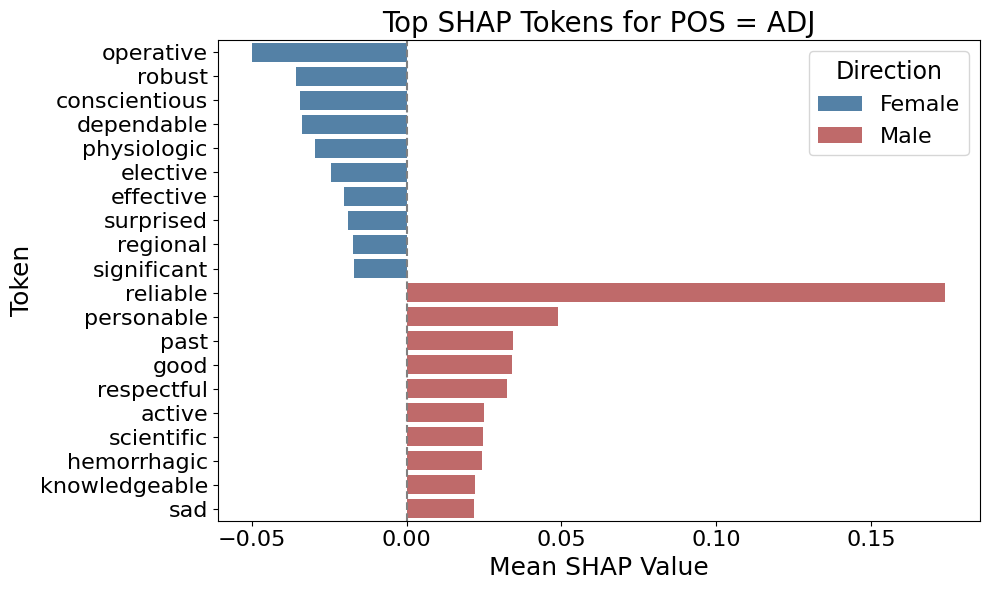

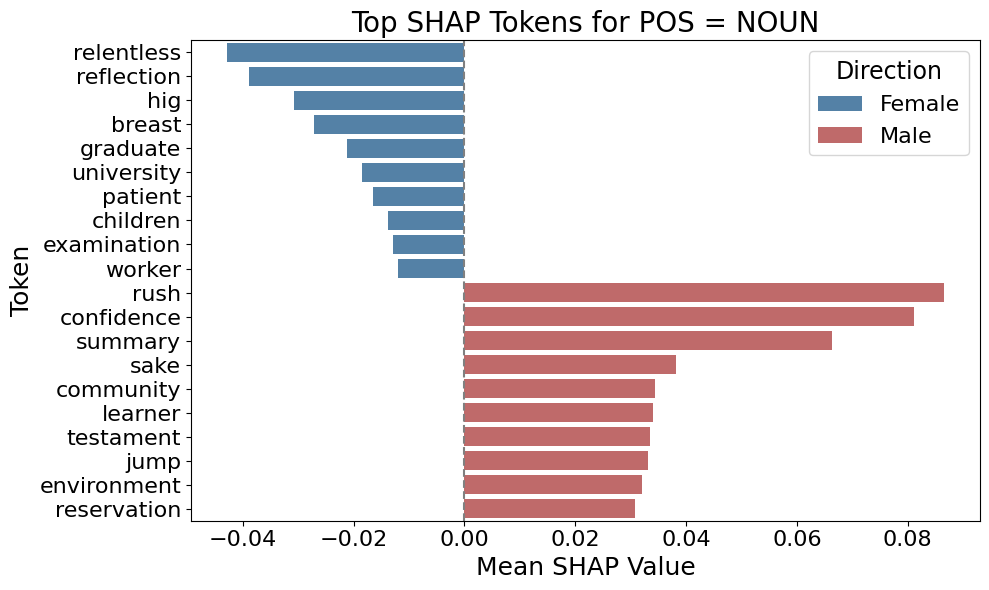

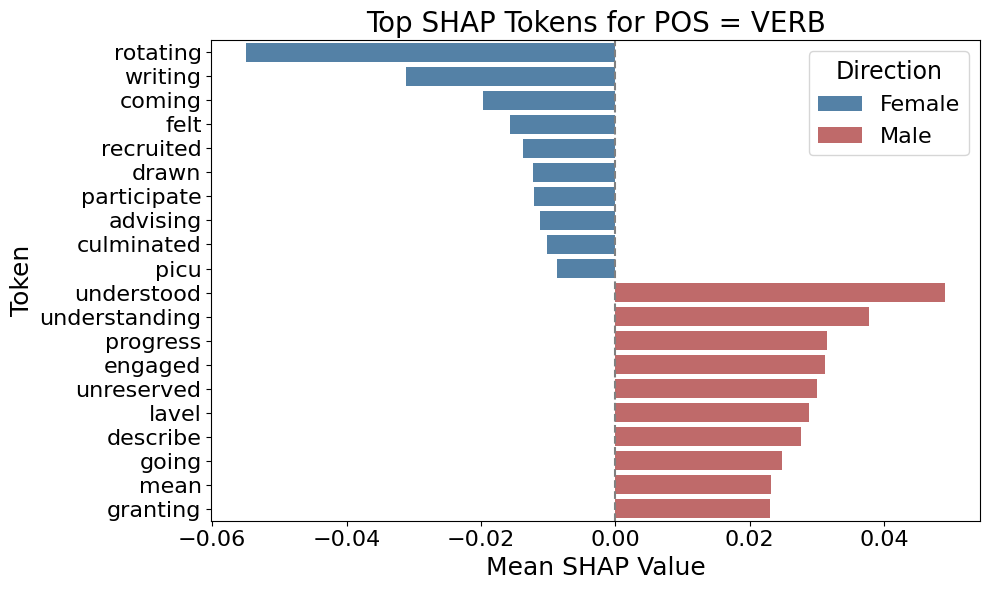

In [ ]:
# adj_male, adj_female = plot_top_shap_by_pos(df_filtered, "ADJ", top_n=10, save_path='../cleaned_figures/distillbert_adj_shap_chart.png')
# noun_male, noun_female = plot_top_shap_by_pos(df_filtered, "NOUN", top_n=10, save_path='../cleaned_figures/distillbert_noun_shap_chart.png')
# verb_male, verb_female = plot_top_shap_by_pos(df_filtered, "VERB", top_n=10, save_path='../cleaned_figures/distillbert_verb_shap_chart.png')

adj_male, adj_female = plot_top_shap_by_pos(df_filtered, "ADJ", top_n=10)
noun_male, noun_female = plot_top_shap_by_pos(df_filtered, "NOUN", top_n=10)
verb_male, verb_female = plot_top_shap_by_pos(df_filtered, "VERB", top_n=10)



# Create Dataset With Implicit Gendered Tokens Removed - SHAP

In [ ]:
import pandas as pd
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
mask_token = tokenizer.mask_token  # '<mask>'

# Token list
token_list = all_tokens.tolist()

# Escape special regex characters
escaped_tokens = [re.escape(token) for token in token_list]
pattern = "(" + "|".join(escaped_tokens) + ")"

# Replace matches with spaced mask token
def mask_text(text):
    return re.sub(pattern, f" {mask_token} ", text)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
df = pd.read_csv('../data/combined_letters_degendered.csv')
# Apply the masking
df["full_text"] = df["full_text"].apply(mask_text)

In [ ]:
# df.to_csv(f"../cleaned_data/implicit_degendered_data/combined_letters_degendered_{model_name}_shap_tokens_removed.csv", index=False)



# Create Dataset With Implicit Gender Tokens Removed - TFIDF

In [ ]:
all_tokens_df = pd.read_csv('../data/top_tokens_tfidf.csv')
all_tokens = all_tokens_df['token']

In [ ]:
import pandas as pd
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
mask_token = tokenizer.mask_token  # '<mask>'

# Token list
token_list = all_tokens.tolist()

# Escape special regex characters
escaped_tokens = [re.escape(token) for token in token_list]
pattern = "(" + "|".join(escaped_tokens) + ")"

# Replace matches with spaced mask token
def mask_text(text):
    return re.sub(pattern, f" {mask_token} ", text)


In [ ]:
df = pd.read_csv('../data/combined_letters_degendered.csv')
# Apply the masking
df["full_text"] = df["full_text"].apply(mask_text)

In [ ]:
df

,full_text,label
0,it is my pleasure to write a letter of recomme...,0
1,i am pleased to highly recommend [MASK] for ...,0
2,i am writing this letter in [MASK] of [MASK...,0
3,[MASK] [MASK] recently [MASK] d an [MASK...,0
4,it is my pleasure to recommend dr. [MASK] fo...,0
...,...,...
8982,it is with pleasure that i recommend first_nam...,0
8983,we are very pleased to write this letter based...,0
8984,i am writing this letter of recommendation for...,1
8985,it is my pleasure to write first_name [MASK] ...,1


In [ ]:
# df.to_csv(f"../cleaned_data/implicit_degendered_data/combined_letters_degendered_{model_name}_tfidf_tokens_removed.csv", index=False)
